# Data Analysis Report

# Steps:

### 1. Import Libraries

### 2. Loading Dataset 

### 3. Basic Information

### 4. Data Cleaning

### 5. Feature Engineering

### 6. Basic Statisctics

### 7. Data Visualization

### 9. Machine Learning

### 10. Conclusion

# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Loading Dataset:

In [3]:
df = pd.read_csv("car details v4.csv")

# View data
print(df.head())

     Car Company                            Model    Price  Year  Kilometer  \
0          Honda              Amaze 1.2 VX i-VTEC   505000  2017      87150   
1  Maruti Suzuki                  Swift DZire VDI   450000  2014      75000   
2        Hyundai             i10 Magna 1.2 Kappa2   220000  2011      67000   
3         Toyota                         Glanza G   799000  2019      37500   
4         Toyota  Innova 2.4 VX 7 STR [2016-2020]  1950000  2018      69000   

  Fuel Type Transmission   Location   Color   Owner Seller Type   Engine  \
0    Petrol       Manual       Pune    Grey   First   Corporate  1198 cc   
1    Diesel       Manual   Ludhiana   White  Second  Individual  1248 cc   
2    Petrol       Manual    Lucknow  Maroon   First  Individual  1197 cc   
3    Petrol       Manual  Mangalore     Red   First  Individual  1197 cc   
4    Diesel       Manual     Mumbai    Grey   First  Individual  2393 cc   

            Max Power              Max Torque Drivetrain  Length   W

# 3. Basic Information

In [4]:
print(df.shape)        # rows, columns
print(df.columns)      # column names
print(df.info())       # data types
print(df.describe())   # statistics

(2059, 20)
Index(['Car Company', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car Company         2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   o

# 4. Data Cleaning

## Check Missing Values

In [5]:
print(df.isnull().sum())

Car Company             0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64


## Handle Missing Values

In [6]:
df = df.dropna()   # simple way (or use fillna)

## Remove Duplicates

In [7]:
df = df.drop_duplicates()

## Convert Data Types

In [8]:
df['Year'] = df['Year'].astype(int)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# 5. Feature Engineering

In [9]:
# Create new column: Car Age
df['Car Age'] = 2024 - df['Year']

# 6. Basic Statistics

In [10]:
print("Average Price:", df['Price'].mean())
print("Max Price:", df['Price'].max())
print("Min Price:", df['Price'].min())

Average Price: 1718279.036819637
Max Price: 35000000
Min Price: 49000


# 7. Data Visualization

## 1. Price Distribution

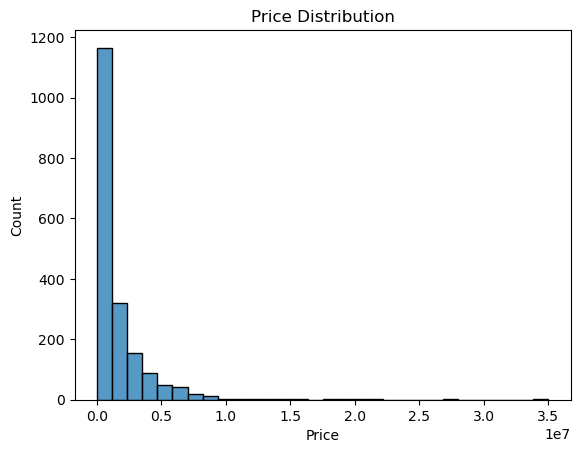

In [11]:
plt.figure()
sns.histplot(df['Price'], bins=30)
plt.title("Price Distribution")
plt.show()

## 2. Fuel Type Count

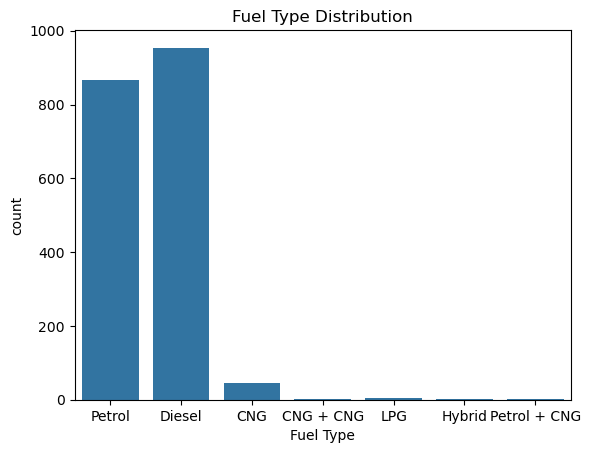

In [12]:
sns.countplot(x='Fuel Type', data=df)
plt.title("Fuel Type Distribution")
plt.show()

## 3. Transmission Type

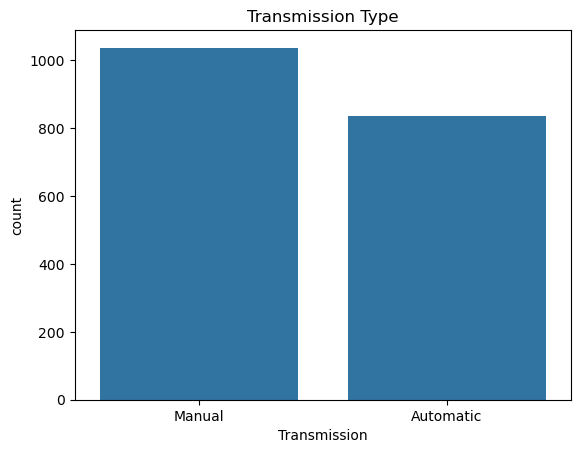

In [13]:
sns.countplot(x='Transmission', data=df)
plt.title("Transmission Type")
plt.show()

## 4. Price vs Year

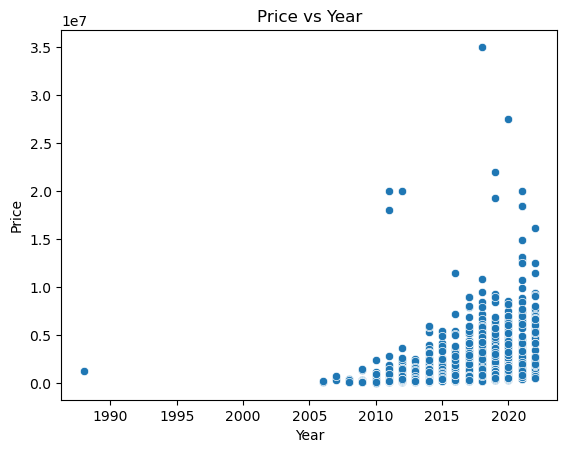

In [14]:
plt.figure()
sns.scatterplot(x='Year', y='Price', data=df)
plt.title("Price vs Year")
plt.show()

## 5. Transmission Distribution

In [ ]:
# 3. Donut Chart: Transmission Distribution
plt.figure(figsize=(5, 5))
trans_counts = df_clean['Transmission'].value_counts()
# The 'wedgeprops' creates the hole in the middle for the donut effect
plt.pie(trans_counts, labels=trans_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=['#ff9999','#66b3ff'], wedgeprops={'width': 0.4})
plt.title('Transmission Distribution ')
plt.show()

## 6. Correlation Heatmap

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# 8. Encoding 

Convert categorical data:

In [ ]:
df = pd.get_dummies(df, drop_first=True)

# 9. Machine Learning

## Predict Car Price

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

## Define X and Y

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Train Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

## Prediction

In [ ]:
y_pred = model.predict(X_test)

## Evaluation

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# 10. Conclusion

Dataset was cleaned by removing missing values and duplicates
Visualization helped understand trends (price, fuel type, etc.)
Machine learning model was applied to predict car prices
Model performance evaluated using MAE and R² score

In [ ]:
# Save cleaned file
df.to_csv("cleaned_car_data.csv", index=False)

print("File saved successfully!")

In [ ]:
import os
print(os.getcwd())

In [ ]:
df.to_csv(r"D:\Data Analytics\cleaned_car_data.csv", index=False)